<a href="https://colab.research.google.com/github/f20250495-del/Keyword-spotting-system/blob/main/Kwd_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

'data' exists but appears empty or incomplete. Cleaning up for fresh download.
Created data directory.
Download complete.
Extracting audio files...
Dataset ready and extracted inside the './data' folder!
Using device: cuda
--- Data Splitting Sanity Check (Speaker-based) ---
Total Audio Samples Found: 11504
Total Unique Speakers (known words): 1791
Train Speakers:      895 (50.0%) Kishan
Validation Speakers: 447 (25.0%) Kishan
Test Speakers:       449 (25.1%) Kishan
Train Set:      5863 files (51.0%) 
Validation Set: 2733 files (23.8%) 
Testing Set:    2908 files (25.3%) 
Total Unique Classes: 5
Returned labels: ['go', 'no', 'stop', 'unknown', 'yes']
Dataset split: 5863 training samples | 2733 validation samples | 2908 test samples
Epoch [01/08] 
  Train Loss: 1.3140 - Train Acc: 46.02%
  Val Loss: 1.0758 - Val Acc: 57.19%
  Validation Metrics (per class):
    Class 'go': P=0.46, R=0.42, F1=0.44
    Class 'no': P=0.53, R=0.45, F1=0.49
    Class 'stop': P=0.74, R=0.73, F1=0.74
    Class 

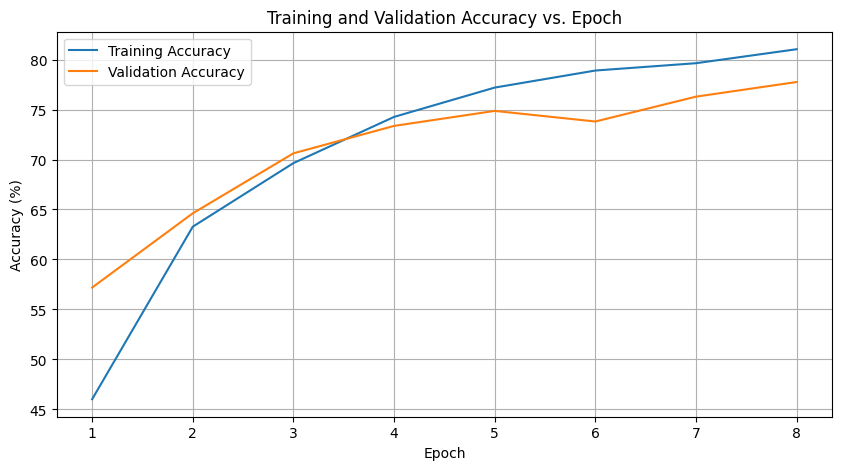


Evaluating best model on Test Set...
Test Loss: 0.6641 - Test Acc: 77.03%
Test Metrics (per class):
  Class 'go': P=0.70, R=0.70, F1=0.70
  Class 'no': P=0.79, R=0.67, F1=0.72
  Class 'stop': P=0.83, R=0.89, F1=0.86
  Class 'unknown': P=0.65, R=0.71, F1=0.68
  Class 'yes': P=0.87, R=0.87, F1=0.87
Test Macro Avg: P=0.77, R=0.77, F1=0.77
Test Weighted Avg: P=0.77, R=0.77, F1=0.77


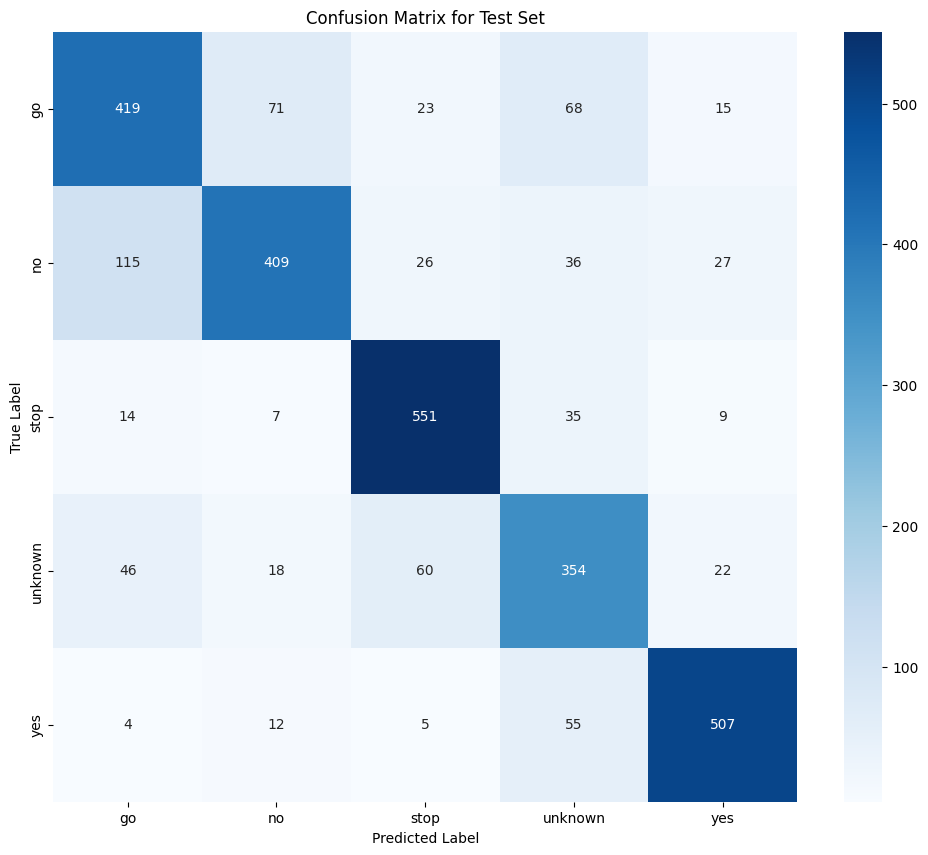

_background_noise_/  five/    marvin/	 right/		   tree/
bed/		     four/    nine/	 seven/		   two/
bird/		     go/      no/	 sheila/	   up/
cat/		     happy/   off/	 six/		   validation_list.txt
dog/		     house/   on/	 stop/		   wow/
down/		     left/    one/	 testing_list.txt  yes/
eight/		     LICENSE  README.md  three/		   zero/


In [11]:
#Most effective :model 4
import os
import tarfile
import urllib.request
import glob
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
import random
from collections import defaultdict
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Download and Extraction ---
DATA_DIR = "data"
# Note: Sticking to V0.01 as present in the user's initial cell for consistency.
# If V0.02 is preferred, the URL below would need to be updated.
URL = "http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz"
ARCHIVE_PATH = os.path.join(DATA_DIR, "speech_commands.tar.gz")

# Check if DATA_DIR exists and contains WAV files
# If not, ensure it's set up correctly by forcing a re-download and extraction
if not os.path.exists(DATA_DIR) or len(glob.glob(os.path.join(DATA_DIR, "*", "*.wav"))) == 0:
    if os.path.exists(DATA_DIR):
        print(f"'{DATA_DIR}' exists but appears empty or incomplete. Cleaning up for fresh download.")
        import shutil
        shutil.rmtree(DATA_DIR) # Remove existing incomplete directory

    os.makedirs(DATA_DIR)
    print(f"Created {DATA_DIR} directory.")

    print("Downloading Google Speech Commands V1 (approx. 1.5GB compressed)...")
    urllib.request.urlretrieve(URL, ARCHIVE_PATH)
    print("Download complete.")

    print("Extracting audio files...")
    # Add filter='data' to address the DeprecationWarning in Python 3.12+
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(path=DATA_DIR, filter='data')

    os.remove(ARCHIVE_PATH)
    print(f"Dataset ready and extracted inside the './{DATA_DIR}' folder!")
else:
    print(f"'{DATA_DIR}' directory already exists and contains data. Skipping download and extraction.")

# --- Definition of get_data_splits ---
def get_data_splits(data_dir, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42):
    """
    Parses the Google Speech Commands directory structure and creates speaker-independent
    train, validation, and test splits with a fixed ratio of speakers.

    Args:
        data_dir (str): Path to the local 'data/' folder containing extracted files.
        train_ratio (float): Proportion of speakers for the training set.
        val_ratio (float): Proportion of speakers for the validation set.
        test_ratio (float): Proportion of speakers for the test set.
        seed (int): Random seed for reproducibility.

    Returns:
        train_list (list), val_list (list), test_list (list), labels (list)
    """
    random.seed(seed)

    # Define the target classes
    target_classes = {'yes', 'no', 'stop', 'go'}

    # Build a dictionary to map speaker_id to a list of their audio files
    speaker_to_files = defaultdict(list)
    unique_labels = set()

    all_wav_paths = glob.glob(os.path.join(data_dir, "*", "*.wav"))

    # Separate unknown files for specific handling
    unknown_files = []

    for full_path in all_wav_paths:
        rel_path = os.path.relpath(full_path, data_dir).replace("\\", "/")
        label = os.path.dirname(rel_path)

        if label.startswith("_") or label == ".pytest_cache":
            continue

        if label in target_classes:
            unique_labels.add(label)
            # Extract speaker_id from filename (e.g., 'dbb40d24' from 'dbb40d24_nohash_2.wav')
            # Assumes format: {speaker_id}_nohash_{index}.wav
            filename = os.path.basename(rel_path)
            speaker_id = filename.split('_')[0] if '_nohash_' in filename else 'unknown_speaker_default'
            speaker_to_files[speaker_id].append(rel_path)
        else:
            unknown_files.append(rel_path)

    # Add 'unknown' label
    if 'unknown' not in unique_labels:
        unique_labels.add('unknown')

    # Sort labels once to get a consistent order for `class_to_idx`
    sorted_labels = sorted(list(unique_labels))

    # --- Speaker-based splitting for known words ---
    all_speakers = list(speaker_to_files.keys())
    # Filter out 'unknown_speaker_default' if it was inadvertently added as a known speaker group.
    # We will handle unknown files separately.
    known_word_speakers = [s for s in all_speakers if s != 'unknown_speaker_default']
    random.shuffle(known_word_speakers)

    num_known_speakers = len(known_word_speakers)
    # Handle case where no known speakers are found to prevent ZeroDivisionError
    if num_known_speakers == 0:
        print("Warning: No known speakers found. This might indicate an issue with data loading or filtering.")
        return [], [], [], sorted_labels # Return empty lists and available labels

    num_train_speakers = int(num_known_speakers * train_ratio)
    num_val_speakers = int(num_known_speakers * val_ratio)
    num_test_speakers = num_known_speakers - num_train_speakers - num_val_speakers

    train_speakers = known_word_speakers[:num_train_speakers]
    val_speakers = known_word_speakers[num_train_speakers : num_train_speakers + num_val_speakers]
    test_speakers = known_word_speakers[num_train_speakers + num_val_speakers :]

    train_list = []
    val_list = []
    test_list = []

    for speaker in train_speakers:
        train_list.extend(speaker_to_files[speaker])
    for speaker in val_speakers:
        val_list.extend(speaker_to_files[speaker])
    for speaker in test_speakers:
        test_list.extend(speaker_to_files[speaker])

    # --- Distribute 'unknown' files explicitly ---
    random.shuffle(unknown_files)
    # Limit the number of unknown files to roughly balance with other classes
    # A more sophisticated approach would count average samples per target class
    # and match that. For now, a fixed cap (e.g., 2000) or a ratio based on total files.
    # Let's say we want to include up to a similar number of unknown files as the average of other classes.
    # For simplicity, we'll take a maximum of 2000 unknown files to be distributed.
    max_unknown_to_distribute = 2000
    selected_unknown_files = unknown_files[:min(len(unknown_files), max_unknown_to_distribute)]

    num_unknown_files = len(selected_unknown_files)
    unknown_train_count = int(num_unknown_files * train_ratio)
    unknown_val_count = int(num_unknown_files * val_ratio)
    unknown_test_count = num_unknown_files - unknown_train_count - unknown_val_count

    train_list.extend(selected_unknown_files[:unknown_train_count])
    val_list.extend(selected_unknown_files[unknown_train_count : unknown_train_count + unknown_val_count])
    test_list.extend(selected_unknown_files[unknown_train_count + unknown_val_count :])

    total_files = len(train_list) + len(val_list) + len(test_list)
    print("--- Data Splitting Sanity Check (Speaker-based) ---")
    print(f"Total Audio Samples Found: {total_files}")
    print(f"Total Unique Speakers (known words): {num_known_speakers}")
    print(f"Train Speakers:      {len(train_speakers)} ({len(train_speakers)/num_known_speakers*100:.1f}%) Kishan")
    print(f"Validation Speakers: {len(val_speakers)} ({len(val_speakers)/num_known_speakers*100:.1f}%) Kishan")
    print(f"Test Speakers:       {len(test_speakers)} ({len(test_speakers)/num_known_speakers*100:.1f}%) Kishan")
    print(f"Train Set:      {len(train_list)} files ({len(train_list)/total_files*100:.1f}%) ")
    print(f"Validation Set: {len(val_list)} files ({len(val_list)/total_files*100:.1f}%) ")
    print(f"Testing Set:    {len(test_list)} files ({len(test_list)/total_files*100:.1f}%) ")
    print(f"Total Unique Classes: {len(sorted_labels)}")
    print(f"Returned labels: {sorted_labels}")

    return train_list, val_list, test_list, sorted_labels

# --- Definition of SpeechDataset ---
class SpeechDataset(Dataset):
    # Modified __init__ to accept file_list, data_dir, and class_to_idx
    def __init__(self, file_list, data_dir, class_to_idx):
        self.file_list = file_list
        self.data_dir = data_dir
        self.class_to_idx = class_to_idx

        self.sample_rate = 16000
        self.n_fft = 512
        self.hop_length = 320
        self.n_mels = 32

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

    def pad_waveform(self, waveform, target_length=16000):
        if waveform.shape[1] < target_length:
            waveform = torch.nn.functional.pad(waveform, (0, target_length - waveform.shape[1]))
        else:
            waveform = waveform[:, :target_length]
        return waveform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        relative_path = self.file_list[idx]
        full_path = os.path.join(self.data_dir, relative_path)

        label_str = os.path.dirname(relative_path)
        # If the label is not in our class_to_idx (i.e., not a target_class and not 'unknown'),
        # it means it was one of the other non-target classes. We should map these to 'unknown'.
        # However, the filtering in get_data_splits should prevent this scenario, but as a safeguard.
        if label_str not in self.class_to_idx:
            label_str = 'unknown' # Map other non-target classes to unknown if they slip through

        current_label = self.class_to_idx[label_str]

        waveform, sr = torchaudio.load(full_path)

        waveform = self.pad_waveform(waveform)
        mel_spec = self.mel_transform(waveform)
        mel_spec_db = self.db_transform(mel_spec)

        return mel_spec_db, current_label

# --- Definition of CustomKWSNet ---
import torch.nn.functional as F

class CustomKWSNet(nn.Module):
    def __init__(self, num_classes):
        super(CustomKWSNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(2, 5), stride=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=(2, 2), stride=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Adjusted for dynamic num_classes
        self.fc = nn.Linear(16 * 3 * 5, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def evaluate_model(model, data_loader, criterion, device, class_to_idx):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_true_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_true_labels, all_preds) * 100

    # Calculate per-class metrics
    # Use the actual labels present in class_to_idx for metrics calculation
    metric_labels = list(range(len(class_to_idx)))

    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
        all_true_labels, all_preds, average=None, labels=metric_labels, zero_division=0
    )

    # Calculate macro, weighted averages
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_true_labels, all_preds, average='macro', labels=metric_labels, zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_true_labels, all_preds, average='weighted', labels=metric_labels, zero_division=0
    )

    # Calculate confusion matrix
    cm = confusion_matrix(all_true_labels, all_preds, labels=metric_labels)

    return avg_loss, accuracy, all_preds, all_true_labels, \
           precision_per_class, recall_per_class, f1_per_class, \
           precision_macro, recall_macro, f1_macro, \
           precision_weighted, recall_weighted, f1_weighted, cm

def train_kws_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 8
    DATA_DIR = "./data"

    # 1. Fetch splits using get_data_splits (now speaker-based with 2:1:1 ratio)
    train_paths, val_paths, test_paths, class_names = get_data_splits( # Renamed 'labels' to 'class_names'
        DATA_DIR, train_ratio=0.5, val_ratio=0.25, test_ratio=0.25
    )

    # If get_data_splits returned empty lists, it means data wasn't found or parsed.
    if not train_paths and not val_paths and not test_paths:
        print("Error: No data found for training. Please check the data download and extraction steps.")
        return # Exit the training function early

    # Create a class_to_idx mapping and get number of classes
    class_to_idx = {label: i for i, label in enumerate(class_names)} # Using 'class_names'
    idx_to_class = {i: label for label, i in class_to_idx.items()}
    num_classes = len(class_names)

    # 2. Instantiate PyTorch Datasets using the split paths
    train_dataset = SpeechDataset(train_paths, DATA_DIR, class_to_idx)
    val_dataset = SpeechDataset(val_paths, DATA_DIR, class_to_idx)
    test_dataset = SpeechDataset(test_paths, DATA_DIR, class_to_idx)

    # 3. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Dataset split: {len(train_dataset)} training samples | {len(val_dataset)} validation samples | {len(test_dataset)} test samples")

    # 4. Model, Loss, and Optimizer Initialization
    model = CustomKWSNet(num_classes=num_classes).to(device) # Pass dynamic num_classes
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_acc = 0.0
    train_accuracies = []
    val_accuracies = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, batch_labels in train_loader: # Renamed 'labels' to 'batch_labels'
            inputs, batch_labels = inputs.to(device), batch_labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += batch_labels.size(0)
            correct_train += (predicted == batch_labels).sum().item()

        epoch_train_loss = running_loss / len(train_dataset)
        epoch_train_acc = (correct_train / total_train) * 100
        train_accuracies.append(epoch_train_acc)

        # Evaluate on validation set
        val_loss, val_acc, _, _, val_precision_per_class, val_recall_per_class, val_f1_per_class, \
        val_precision_macro, val_recall_macro, val_f1_macro, val_precision_weighted, val_recall_weighted, val_f1_weighted, _ = \
            evaluate_model(model, val_loader, criterion, device, class_to_idx)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] ")
        print(f"  Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%")

        print("  Validation Metrics (per class):")
        for i, label_name in idx_to_class.items():
            print(f"    Class '{label_name}': P={val_precision_per_class[i]:.2f}, R={val_recall_per_class[i]:.2f}, F1={val_f1_per_class[i]:.2f}")
        print(f"  Validation Macro Avg: P={val_precision_macro:.2f}, R={val_recall_macro:.2f}, F1={val_f1_macro:.2f}")
        print(f"  Validation Weighted Avg: P={val_precision_weighted:.2f}, R={val_recall_weighted:.2f}, F1={val_f1_weighted:.2f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_kws_model.pth")
            print(f"  --> Saved new best checkpoint! (Val Acc: {best_val_acc:.2f}%) Kishan")

    print("\nTraining completed successfully!")

    # Plotting training and validation accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, EPOCHS + 1), train_accuracies, label='Training Accuracy')
    plt.plot(range(1, EPOCHS + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy vs. Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Load best model for testing
    model.load_state_dict(torch.load("best_kws_model.pth"))
    print("\nEvaluating best model on Test Set...")
    test_loss, test_acc, _, _, test_precision_per_class, test_recall_per_class, test_f1_per_class, \
    test_precision_macro, test_recall_macro, test_f1_macro, test_precision_weighted, test_recall_weighted, test_f1_weighted, test_cm = \
        evaluate_model(model, test_loader, criterion, device, class_to_idx)

    print(f"Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.2f}%")
    print("Test Metrics (per class):")
    for i, label_name in idx_to_class.items():
        print(f"  Class '{label_name}': P={test_precision_per_class[i]:.2f}, R={test_recall_per_class[i]:.2f}, F1={test_f1_per_class[i]:.2f}")
    print(f"Test Macro Avg: P={test_precision_macro:.2f}, R={test_recall_macro:.2f}, F1={test_f1_macro:.2f}")
    print(f"Test Weighted Avg: P={test_precision_weighted:.2f}, R={test_recall_weighted:.2f}, F1={test_f1_weighted:.2f}")

    # Plotting Confusion Matrix for Test Set
    plt.figure(figsize=(12, 10))
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names) # Using 'class_names'
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for Test Set')
    plt.show()

if __name__ == "__main__":
    train_kws_model()

 # List the contents of the 'data' directory to see the downloaded dataset structure
!ls -F data










In [1]:

import torch
import torchaudio
import torchaudio.transforms as T
import argparse
import os

# ── CONFIG (config with training data) ─────────────────────
SAMPLE_RATE   = 16000
N_FFT         = 512
HOP_LENGTH    = 320
N_MELS        = 32
MAX_LENGTH    = 16000  # 1 second
CLASS_LABELS  = ['go', 'no', 'stop', 'unknown', 'yes']
MODEL_PATH    = 'best_kws_model.pth'  # adjust to your saved model path

# ── YOUR MODEL CLASS (Specify model architecture) ──────────────
import torch.nn as nn

class KeywordCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8,  kernel_size=(2,5), stride=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=(2,2), stride=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.fc    = nn.Linear(240, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ── PREPROCESSING ────────────────────────────────────────────────
def preprocess(wav_path):
    waveform, sr = torchaudio.load(wav_path)

    # Convert to mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample if needed
    if sr != SAMPLE_RATE:
        resampler = T.Resample(sr, SAMPLE_RATE)
        waveform  = resampler(waveform)

    # Pad or truncate to 1 second
    num_samples = waveform.shape[1]
    if num_samples < MAX_LENGTH:
        pad = MAX_LENGTH - num_samples
        waveform = torch.nn.functional.pad(waveform, (0, pad))
    else:
        waveform = waveform[:, :MAX_LENGTH]

    # Mel spectrogram
    mel_transform = T.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    db_transform = T.AmplitudeToDB()

    mel = mel_transform(waveform)
    mel = db_transform(mel)

    # Add batch dimension → (1, 1, 32, 51)
    mel = mel.unsqueeze(0)
    return mel

# ── INFERENCE ────────────────────────────────────────────────────
def predict(wav_path):
    if not os.path.exists(wav_path):
        print(f"Error: File not found — {wav_path}")
        return

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load model
    model = KeywordCNN(num_classes=5).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    # Preprocess
    mel = preprocess(wav_path).to(device)

    # Predict
    with torch.no_grad():
        output     = model(mel)
        probs      = torch.softmax(output, dim=1)
        confidence = probs.max().item()
        pred_idx   = probs.argmax().item()
        pred_label = CLASS_LABELS[pred_idx]

    print(f"\nFile: {wav_path}")
    print(f"Predicted keyword: {pred_label.upper()}")
    print(f"Confidence: {confidence*100:.1f}%")
    print("\nAll class probabilities:")
    for label, prob in zip(CLASS_LABELS, probs[0]):
        bar = '█' * int(prob.item() * 20)
        print(f"  {label:10s} {prob.item()*100:5.1f}%  {bar}")

    return pred_label, confidence

# ── MAIN ─────────────────────────────────────────────────────────
if __name__ == '__main__':

     sample_wav_path = 'data/seven/004ae714_nohash_0.wav' # Replace with an actual file from your dataset
     predict(sample_wav_path)

print("To run inference, uncomment and modify the `predict` function call with a .wav file path.")
print("Example: `predict('004ae714_nohash_1.wav')`")




Error: File not found — data/seven/004ae714_nohash_0.wav
To run inference, uncomment and modify the `predict` function call with a .wav file path.
Example: `predict('004ae714_nohash_1.wav')`


In [14]:
# List a few files from the 'seven' directory to pick one
seven_files = !ls -F data/seven | head -n 3
print("Example files in data/seven:")
for f in seven_files:
    print(f)

# Construct a full path using one of the listed files
# Let's pick the first one, or you can choose any other
if seven_files:
    example_relative_path = os.path.join("seven", seven_files[0].strip())
    full_filepath = os.path.join(DATA_DIR, example_relative_path)
    print(f"\nConstructed full filepath: {full_filepath}")

    # Now you can use this full filepath with the predict function
    predict(full_filepath)
else:
    print("No files found in 'data/seven' to demonstrate.")

Example files in data/seven:
004ae714_nohash_0.wav
004ae714_nohash_1.wav
004ae714_nohash_2.wav

Constructed full filepath: data/seven/004ae714_nohash_0.wav

File: data/seven/004ae714_nohash_0.wav
Predicted keyword: STOP
Confidence: 56.8%

All class probabilities:
  go           0.5%  
  no           0.0%  
  stop        56.8%  ███████████
  unknown     21.5%  ████
  yes         21.1%  ████


In [ ]:
sample_wav_path = 'data/go/0a7c2a8d_nohash_0.wav' # Example path, replace with your .wav file
predict(sample_wav_path)

In [2]:
#Model 1

import os
import tarfile
import urllib.request
import glob
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
import random
from collections import defaultdict
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Download and Extraction ---
DATA_DIR = "data"
# Note: Sticking to V0.01 as present in the user's initial cell for consistency.
# If V0.02 is preferred, the URL below would need to be updated.
URL = "http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz"
ARCHIVE_PATH = os.path.join(DATA_DIR, "speech_commands.tar.gz")

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(f"Created {DATA_DIR} directory.")

    print("Downloading Google Speech Commands V1 (approx. 1.5GB compressed)...")
    urllib.request.urlretrieve(URL, ARCHIVE_PATH)
    print("Download complete.")

    print("Extracting audio files...")
    # Add filter='data' to address the DeprecationWarning in Python 3.12+
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(path=DATA_DIR, filter='data')

    os.remove(ARCHIVE_PATH)
    print(f"Dataset ready and extracted inside the './{DATA_DIR}' folder!")

# --- Definition of get_data_splits ---
def get_data_splits(data_dir, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42):
    """
    Parses the Google Speech Commands directory structure and creates speaker-independent
    train, validation, and test splits with a fixed ratio of speakers.

    Args:
        data_dir (str): Path to the local 'data/' folder containing extracted files.
        train_ratio (float): Proportion of speakers for the training set.
        val_ratio (float): Proportion of speakers for the validation set.
        test_ratio (float): Proportion of speakers for the test set.
        seed (int): Random seed for reproducibility.

    Returns:
        train_list (list), val_list (list), test_list (list), labels (list)
    """
    random.seed(seed)

    # Define the target classes
    target_classes = {'yes', 'no', 'stop', 'go'}

    # Build a dictionary to map speaker_id to a list of their audio files
    speaker_to_files = defaultdict(list)
    unique_labels = set()

    all_wav_paths = glob.glob(os.path.join(data_dir, "*", "*.wav"))

    # Separate unknown files for specific handling
    unknown_files = []

    for full_path in all_wav_paths:
        rel_path = os.path.relpath(full_path, data_dir).replace("\\", "/")
        label = os.path.dirname(rel_path)

        if label.startswith("_") or label == ".pytest_cache":
            continue

        if label in target_classes:
            unique_labels.add(label)
            # Extract speaker_id from filename (e.g., 'dbb40d24' from 'dbb40d24_nohash_2.wav')
            # Assumes format: {speaker_id}_nohash_{index}.wav
            filename = os.path.basename(rel_path)
            speaker_id = filename.split('_')[0] if '_nohash_' in filename else 'unknown_speaker'
            speaker_to_files[speaker_id].append(rel_path)
        else:
            unknown_files.append(rel_path)

    # Add 'unknown' label and a balanced number of 'unknown' files
    if 'unknown' not in unique_labels:
        unique_labels.add('unknown')

    # Take a random subset of 'unknown' files equal to the number of files in 'yes' for example,
    # or a fixed number to balance the dataset. Let's aim for a similar number of samples.
    # For simplicity, we'll just add some 'unknown' files.
    # A more sophisticated approach would involve counting samples per target class
    # and then sampling 'unknown' files to match the size of one of the target classes
    # or a desired ratio.
    num_target_class_samples = sum(len(speaker_to_files[s]) for s in speaker_to_files if os.path.dirname(speaker_to_files[s][0]) in target_classes)

    # Roughly balance 'unknown' class, or ensure its presence. If there are many unknown files,
    # we can limit them to a similar count as an average of other target classes, or just some fixed number.
    # Here, for simplicity, we'll try to add up to 2000 unknown files to the speaker-to-files structure.
    random.shuffle(unknown_files)
    selected_unknown_files = unknown_files[:min(len(unknown_files), 2000)] # Limit to 2000 for example

    # Assign these unknown files to an 'unknown_speaker' or distribute them if needed.
    # For speaker independence, it's safer to treat them as belonging to a single 'unknown_speaker' if we can't extract unique speakers.
    if selected_unknown_files:
        # Group all selected unknown files under a generic 'unknown_speaker' ID
        # This might not be speaker-independent if 'unknown' files have true speaker IDs but they are not extracted
        # For now, this is a pragmatic way to include them.
        speaker_to_files['unknown_speaker_group'] = [f for f in selected_unknown_files]


    sorted_labels = sorted(list(unique_labels)) # Re-sort to include 'unknown'

    # Get all unique speakers (now including 'unknown_speaker_group' if applicable)
    all_speakers = list(speaker_to_files.keys())
    random.shuffle(all_speakers)

    # Calculate number of speakers for each split
    num_speakers = len(all_speakers)
    num_train_speakers = int(num_speakers * train_ratio)
    num_val_speakers = int(num_speakers * val_ratio)
    # Test speakers take the remainder to ensure all speakers are used
    num_test_speakers = num_speakers - num_train_speakers - num_val_speakers

    # Assign speakers to splits
    train_speakers = all_speakers[:num_train_speakers]
    val_speakers = all_speakers[num_train_speakers : num_train_speakers + num_val_speakers]
    test_speakers = all_speakers[num_train_speakers + num_val_speakers :]

    # Collect files for each split based on speaker assignment
    train_list = []
    val_list = []
    test_list = []

    for speaker in train_speakers:
        train_list.extend(speaker_to_files[speaker])
    for speaker in val_speakers:
        val_list.extend(speaker_to_files[speaker])
    for speaker in test_speakers:
        test_list.extend(speaker_to_files[speaker])

    total_files = len(train_list) + len(val_list) + len(test_list)
    print("--- Data Splitting Sanity Check (Speaker-based) ---")
    print(f"Total Audio Samples Found: {total_files}")
    print(f"Total Unique Speakers: {num_speakers}")
    print(f"Train Speakers:      {len(train_speakers)} ({len(train_speakers)/num_speakers*100:.1f}%)ادث")
    print(f"Validation Speakers: {len(val_speakers)} ({len(val_speakers)/num_speakers*100:.1f}%)اد")
    print(f"Test Speakers:       {len(test_speakers)} ({len(test_speakers)/num_speakers*100:.1f}%)اد")
    print(f"Train Set:      {len(train_list)} files ({len(train_list)/total_files*100:.1f}%)ادث")
    print(f"Validation Set: {len(val_list)} files ({len(val_list)/total_files*100:.1f}%) ")
    print(f"Testing Set:    {len(test_list)} files ({len(test_list)/total_files*100:.1f}%) ")
    print(f"Total Unique Classes: {len(sorted_labels)}")
    print(f"Returned labels: {sorted_labels}") # Added this print statement

    return train_list, val_list, test_list, sorted_labels

# --- Definition of SpeechDataset ---
class SpeechDataset(Dataset):
    # Modified __init__ to accept file_list, data_dir, and class_to_idx
    def __init__(self, file_list, data_dir, class_to_idx):
        self.file_list = file_list
        self.data_dir = data_dir
        self.class_to_idx = class_to_idx

        self.sample_rate = 16000
        self.n_fft = 512
        self.hop_length = 320
        self.n_mels = 32

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

    def pad_waveform(self, waveform, target_length=16000):
        if waveform.shape[1] < target_length:
            waveform = torch.nn.functional.pad(waveform, (0, target_length - waveform.shape[1]))
        else:
            waveform = waveform[:, :target_length]
        return waveform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        relative_path = self.file_list[idx]
        full_path = os.path.join(self.data_dir, relative_path)

        label_str = os.path.dirname(relative_path)
        # If the label is not in our class_to_idx (i.e., not a target_class and not 'unknown'),
        # it means it was one of the other non-target classes. We should map these to 'unknown'.
        # However, the filtering in get_data_splits should prevent this scenario, but as a safeguard.
        if label_str not in self.class_to_idx:
            label_str = 'unknown' # Map other non-target classes to unknown if they slip through

        current_label = self.class_to_idx[label_str]

        waveform, sr = torchaudio.load(full_path)

        waveform = self.pad_waveform(waveform)
        mel_spec = self.mel_transform(waveform)
        mel_spec_db = self.db_transform(mel_spec)

        return mel_spec_db, current_label

# --- Definition of CustomKWSNet ---
import torch.nn.functional as F

class CustomKWSNet(nn.Module):
    def __init__(self, num_classes):
        super(CustomKWSNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(2, 3), stride=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=(2, 2), stride=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Adjusted for dynamic num_classes
        self.fc = nn.Linear(16 * 3 * 5, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def evaluate_model(model, data_loader, criterion, device, class_to_idx):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_true_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_true_labels, all_preds) * 100

    # Calculate per-class metrics
    # Use the actual labels present in class_to_idx for metrics calculation
    metric_labels = list(range(len(class_to_idx)))

    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
        all_true_labels, all_preds, average=None, labels=metric_labels, zero_division=0
    )

    # Calculate macro, weighted averages
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_true_labels, all_preds, average='macro', labels=metric_labels, zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_true_labels, all_preds, average='weighted', labels=metric_labels, zero_division=0
    )

    # Calculate confusion matrix
    cm = confusion_matrix(all_true_labels, all_preds, labels=metric_labels)

    return avg_loss, accuracy, all_preds, all_true_labels, \
           precision_per_class, recall_per_class, f1_per_class, \
           precision_macro, recall_macro, f1_macro, \
           precision_weighted, recall_weighted, f1_weighted, cm

def train_kws_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 15
    DATA_DIR = "./data"

    # 1. Fetch splits using get_data_splits (now speaker-based with 2:1:1 ratio)
    train_paths, val_paths, test_paths, labels = get_data_splits(
        DATA_DIR, train_ratio=0.5, val_ratio=0.25, test_ratio=0.25
    )

    # Create a class_to_idx mapping and get number of classes
    class_to_idx = {label: i for i, label in enumerate(labels)}
    idx_to_class = {i: label for label, i in class_to_idx.items()}
    num_classes = len(labels)

    # 2. Instantiate PyTorch Datasets using the split paths
    train_dataset = SpeechDataset(train_paths, DATA_DIR, class_to_idx)
    val_dataset = SpeechDataset(val_paths, DATA_DIR, class_to_idx)
    test_dataset = SpeechDataset(test_paths, DATA_DIR, class_to_idx)

    # 3. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Dataset split: {len(train_dataset)} training samples | {len(val_dataset)} validation samples | {len(test_dataset)} test samples")

    # 4. Model, Loss, and Optimizer Initialization
    model = CustomKWSNet(num_classes=num_classes).to(device) # Pass dynamic num_classes
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_acc = 0.0
    train_accuracies = []
    val_accuracies = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_dataset)
        epoch_train_acc = (correct_train / total_train) * 100
        train_accuracies.append(epoch_train_acc)

        # Evaluate on validation set
        val_loss, val_acc, _, _, val_precision_per_class, val_recall_per_class, val_f1_per_class, \
        val_precision_macro, val_recall_macro, val_f1_macro, val_precision_weighted, val_recall_weighted, val_f1_weighted, _ = \
            evaluate_model(model, val_loader, criterion, device, class_to_idx)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] ")
        print(f"  Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%")

        print("  Validation Metrics (per class):")
        for i, label_name in idx_to_class.items():
            print(f"    Class '{label_name}': P={val_precision_per_class[i]:.2f}, R={val_recall_per_class[i]:.2f}, F1={val_f1_per_class[i]:.2f}")
        print(f"  Validation Macro Avg: P={val_precision_macro:.2f}, R={val_recall_macro:.2f}, F1={val_f1_macro:.2f}")
        print(f"  Validation Weighted Avg: P={val_precision_weighted:.2f}, R={val_recall_weighted:.2f}, F1={val_f1_weighted:.2f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_kws_model.pth")
            print(f"  --> Saved new best checkpoint! (Val Acc: {best_val_acc:.2f}%) Kishan")

    print("\nTraining completed successfully!")

    # Plotting training and validation accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, EPOCHS + 1), train_accuracies, label='Training Accuracy')
    plt.plot(range(1, EPOCHS + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy vs. Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Load best model for testing
    model.load_state_dict(torch.load("best_kws_model.pth"))
    print("\nEvaluating best model on Test Set...")
    test_loss, test_acc, _, _, test_precision_per_class, test_recall_per_class, test_f1_per_class, \
    test_precision_macro, test_recall_macro, test_f1_macro, test_precision_weighted, test_recall_weighted, test_f1_weighted, test_cm = \
        evaluate_model(model, test_loader, criterion, device, class_to_idx)

    print(f"Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.2f}%")
    print("Test Metrics (per class):")
    for i, label_name in idx_to_class.items():
        print(f"  Class '{label_name}': P={test_precision_per_class[i]:.2f}, R={test_recall_per_class[i]:.2f}, F1={test_f1_per_class[i]:.2f}")
    print(f"Test Macro Avg: P={test_precision_macro:.2f}, R={test_recall_macro:.2f}, F1={test_f1_macro:.2f}")
    print(f"Test Weighted Avg: P={test_precision_weighted:.2f}, R={test_recall_weighted:.2f}, F1={test_f1_weighted:.2f}")

    # Plotting Confusion Matrix for Test Set
    plt.figure(figsize=(12, 10))
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for Test Set')
    plt.show()

if __name__ == "__main__":
    train_kws_model()

Using device: cuda
--- Data Splitting Sanity Check (Speaker-based) ---
Total Audio Samples Found: 11504
Total Unique Speakers: 1792
Train Speakers:      896 (50.0%)ادث
Validation Speakers: 448 (25.0%)اد
Test Speakers:       448 (25.0%)اد
Train Set:      6738 files (58.6%)ادث
Validation Set: 2384 files (20.7%) 
Testing Set:    2382 files (20.7%) 
Total Unique Classes: 5
Returned labels: ['go', 'no', 'stop', 'unknown', 'yes']
Dataset split: 6738 training samples | 2384 validation samples | 2382 test samples


KeyboardInterrupt: 